# Decision Tree Project

In [ ]:
#Importamos las librerias a usar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from Functions import uninum, unicat, bicat, binum, multiV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree
from pickle import dump, load

### 1. Obtenemos los Datos, y realizamos el ETL

In [ ]:
df = pd.read_csv('/workspaces/P19-Decision-Tree/data/raw/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#Verificacion de duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
#Renombramos Columnas
df.rename(columns={'BMI' :'IMC'}, inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
#Evaluamos las estadísticas descriptivas del DataFrame
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 2. Analisis Exploratorio (EDA)

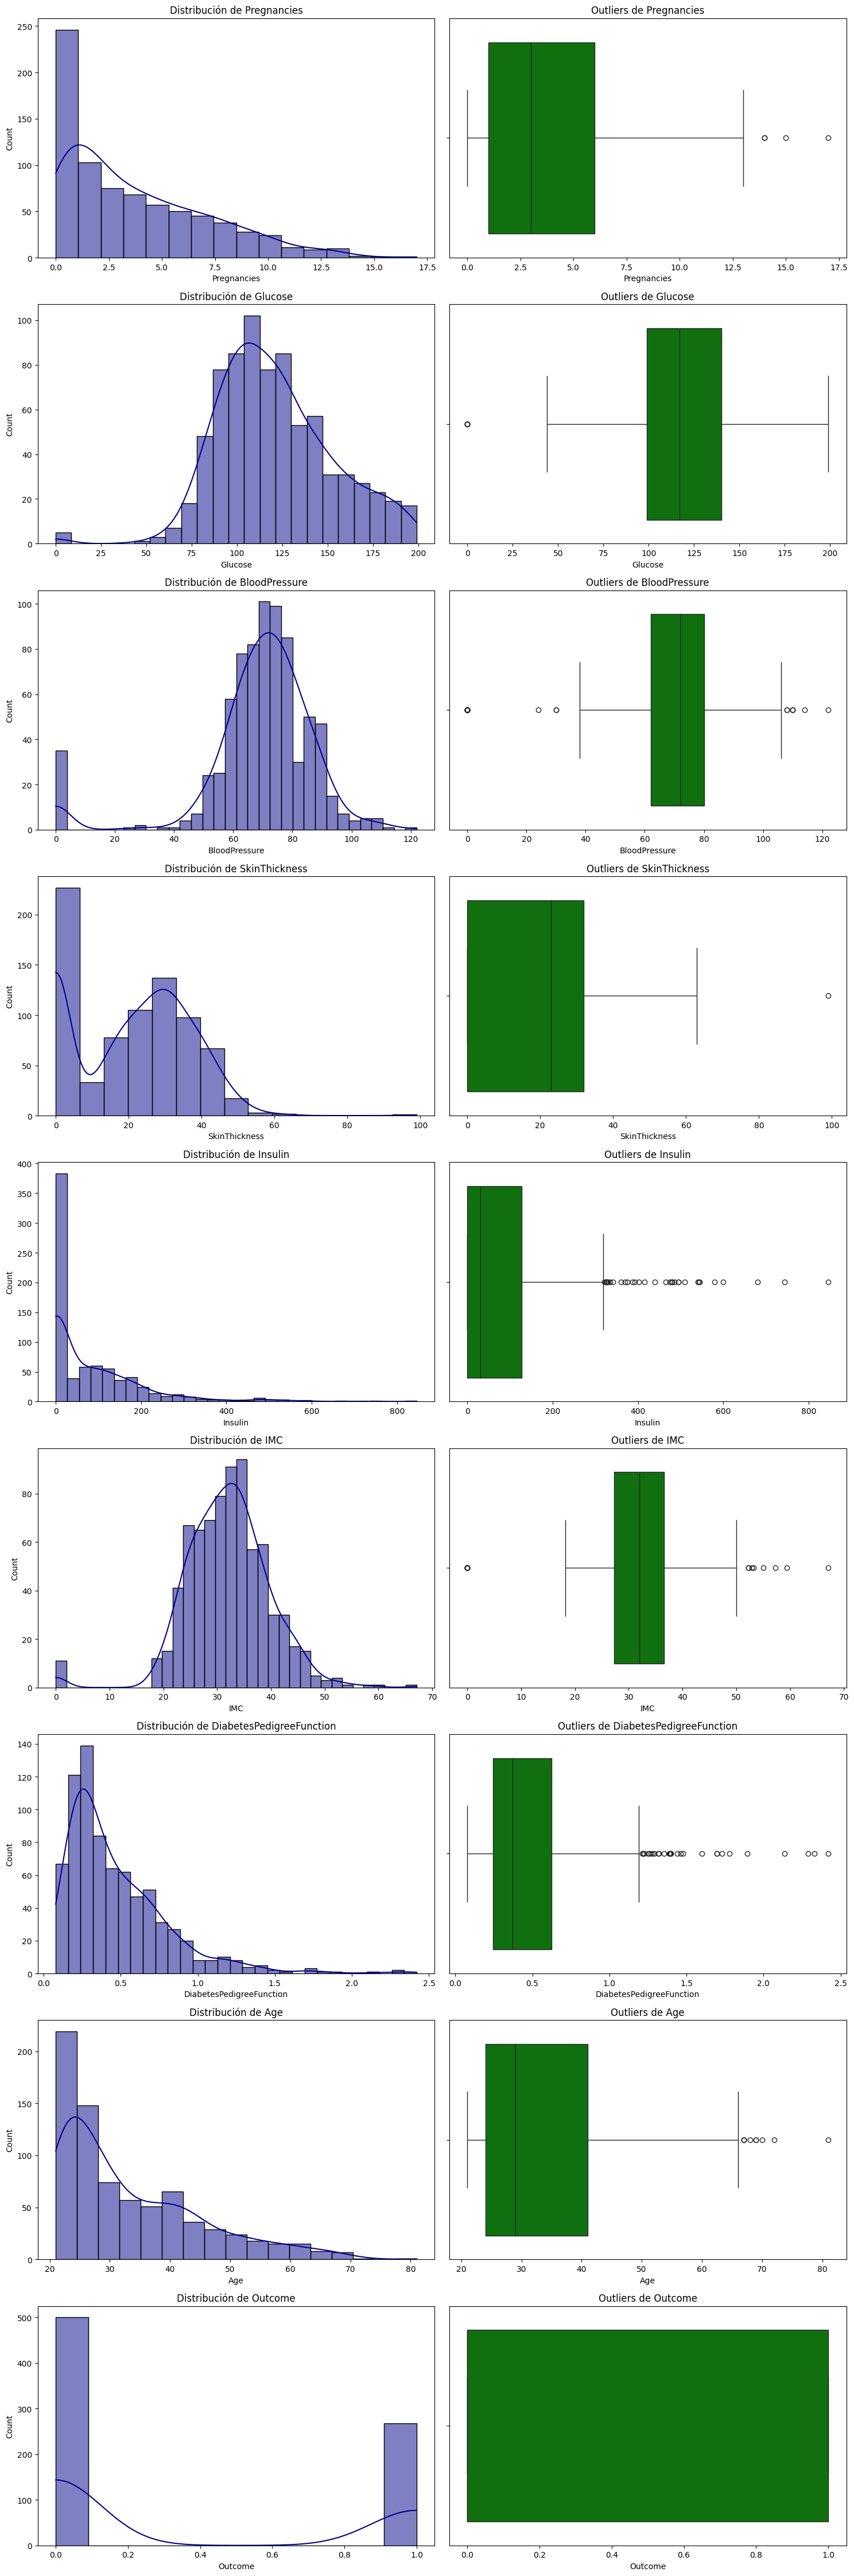

In [ ]:
### 2.1 Analisis Univariante Numerico
uninum(df)

In [ ]:
#Aplicamos filtros condicionales sobre DiabetesPedigreeFunction, IMC e Insulin
df = df[df['Insulin'] <= 200 ]
df = df[df['DiabetesPedigreeFunction'] <= 1 ]
df = df[(df['IMC'] <= 55) & (df['IMC']>10)]

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DiabetesPedigreeFunction,Age,Outcome
count,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000
mean,3.843106,116.836767,68.676704,18.898574,48.350238,31.783518,0.402369,33.099842,0.310618
std,3.350780,30.464139,19.031388,15.782123,61.845373,6.551281,0.220343,11.799563,0.463114
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,97.000000,62.000000,0.000000,0.000000,26.950000,0.235000,24.000000,0.000000
50%,3.000000,112.000000,70.000000,20.000000,0.000000,31.600000,0.340000,29.000000,0.000000
75%,6.000000,134.500000,78.000000,31.000000,94.000000,35.750000,0.551000,40.500000,1.000000
max,17.000000,197.000000,122.000000,99.000000,200.000000,55.000000,0.997000,81.000000,1.000000


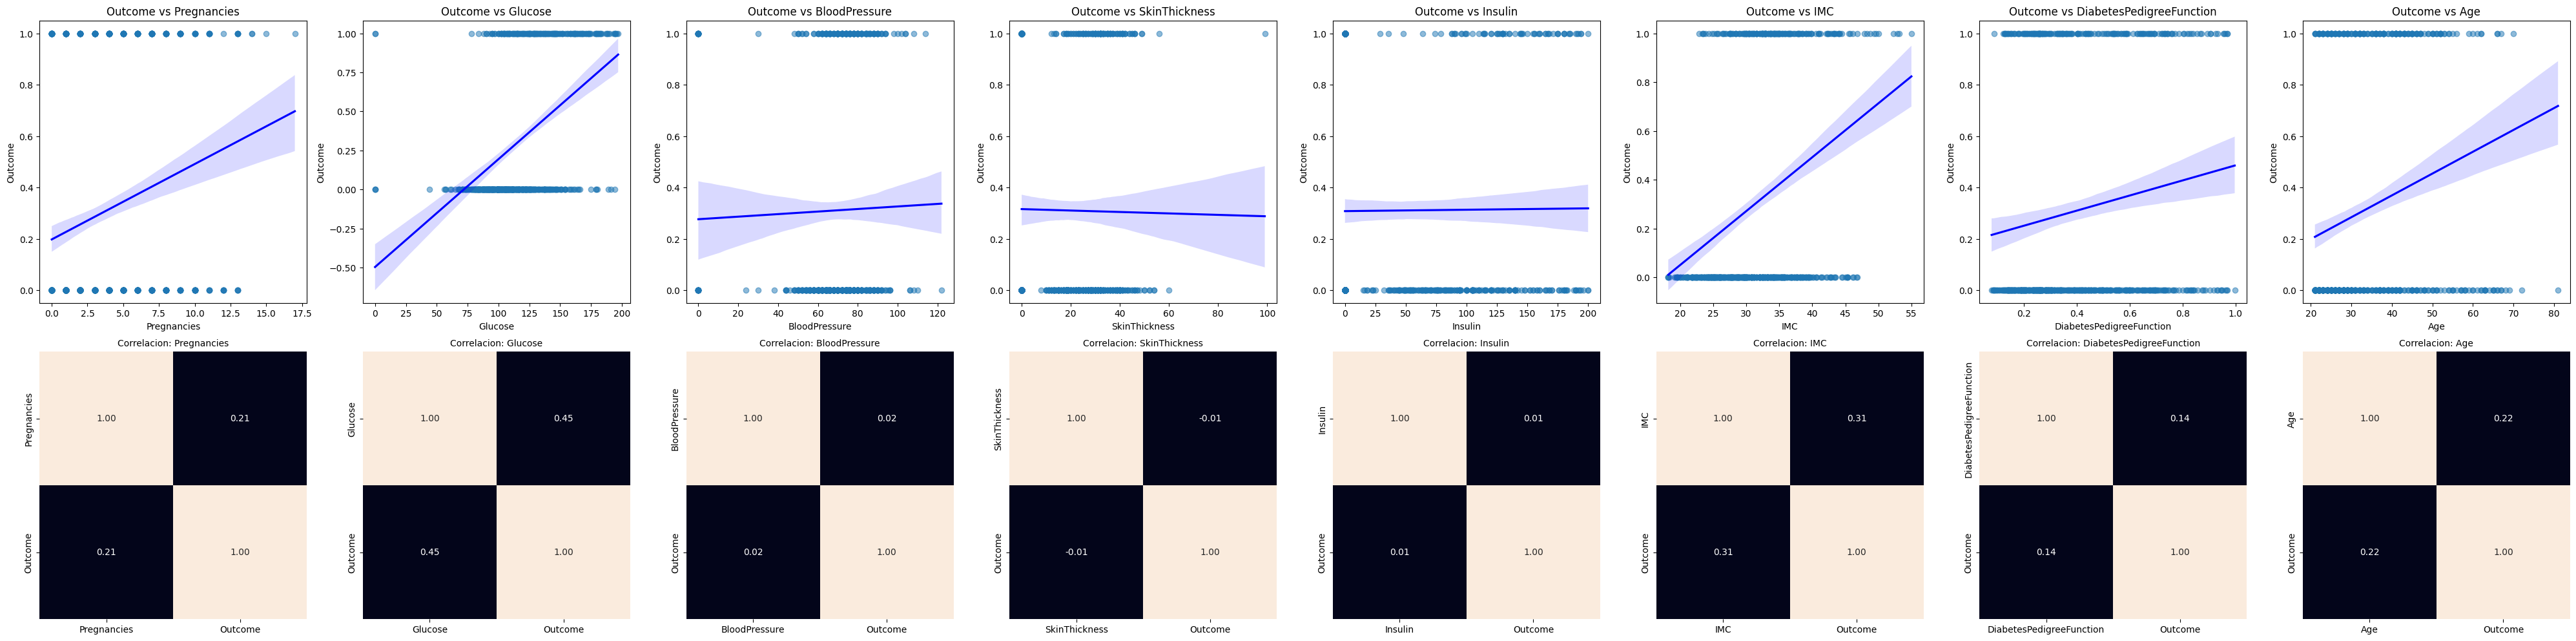

In [ ]:
# 2.2 Analisis Bivariable Numerico
binum(df, 'Outcome')

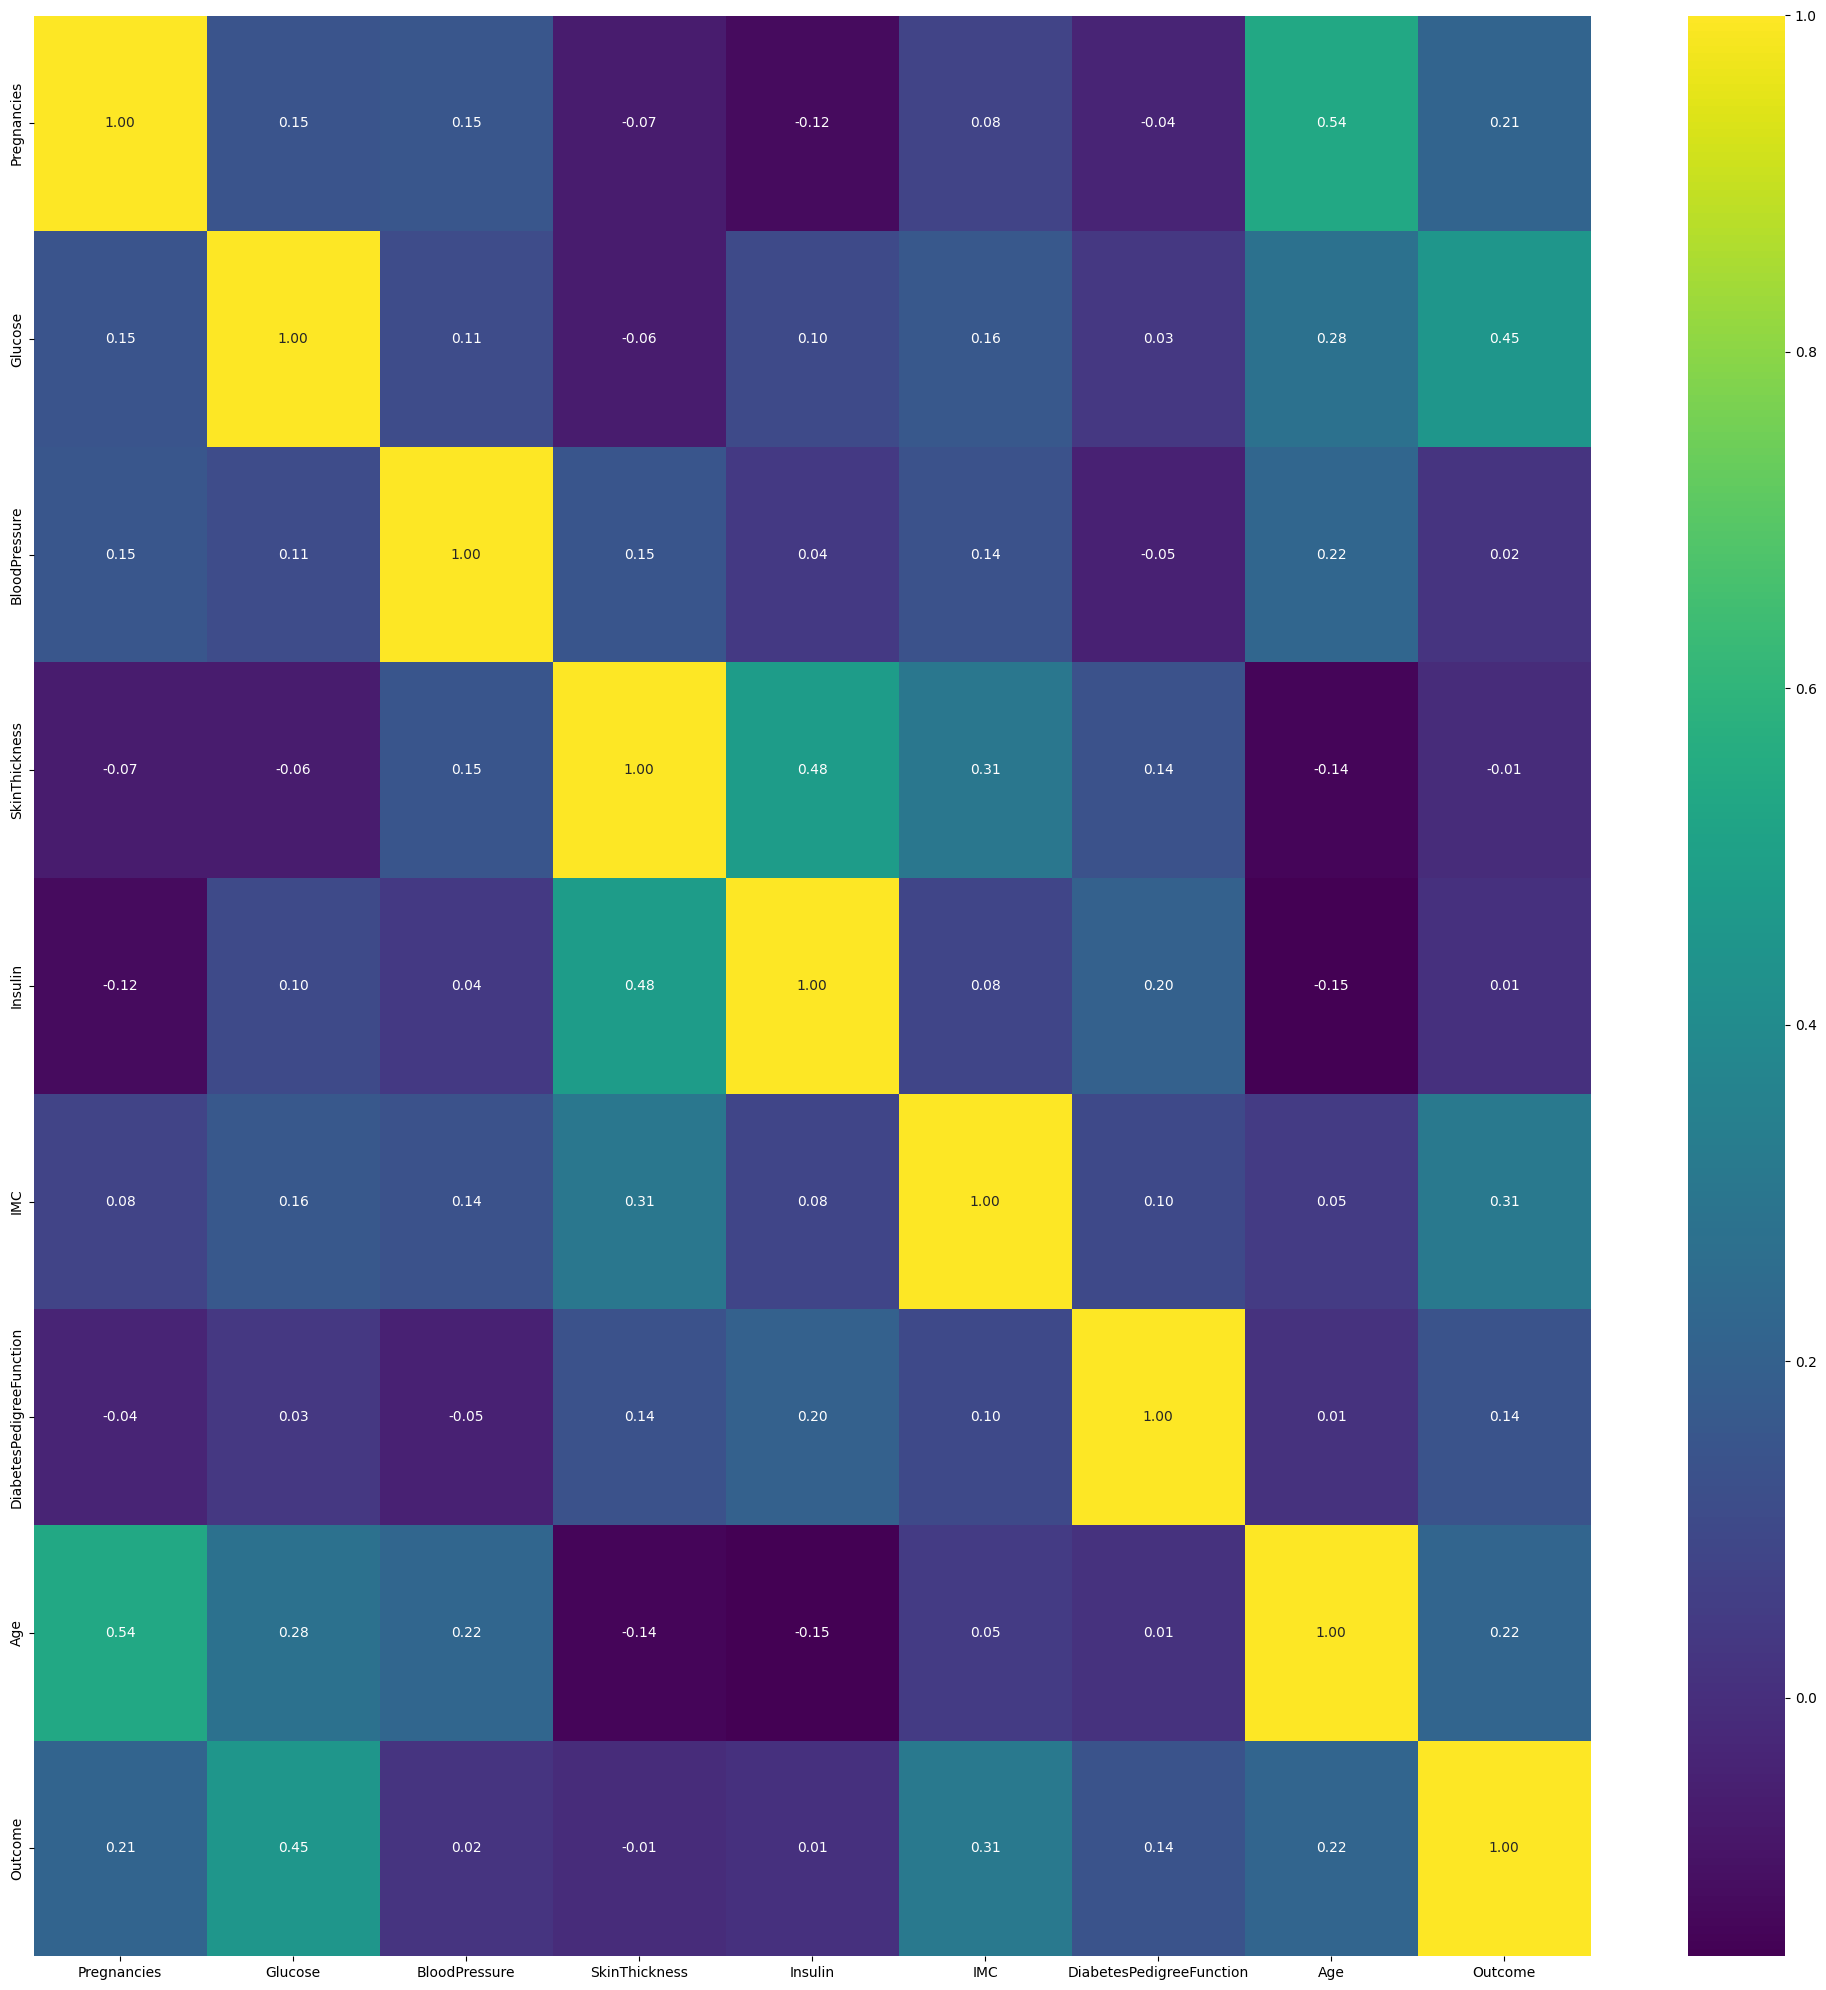

In [ ]:
# 2.3 Analisis de Correlacion

plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot= True, fmt='.2f', cmap='viridis')

plt.tight_layout()
plt.show()

## 3. Seleccion de Caracteristicas

In [ ]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

sk = SelectKBest(score_func=f_classif, k=4)
sk.fit(X_train, y_train)

sf = sk.get_support(indices=True)

X_train_sel = pd.DataFrame(sk.transform(X_train), columns=X_train.columns[sf])
X_test_sel = pd.DataFrame(sk.transform(X_test), columns=X_test.columns[sf])

X_train_sel.head()

,Pregnancies,Glucose,IMC,Age
0,10.0,115.0,35.3,29.0
1,1.0,118.0,33.3,23.0
2,3.0,128.0,21.1,55.0
3,10.0,68.0,35.5,47.0
4,8.0,194.0,26.1,67.0


In [ ]:
# Guardamos los datos de entrenamiento y prueba en archivos Excel

X_train_sel['Outcome'] = y_train.values
X_test_sel['Outcome'] = y_test.values

X_train_sel.to_excel('/workspaces/P19-Decision-Tree/data/processed/X_train_sel.xlsx', index=False)
X_test_sel.to_excel('/workspaces/P19-Decision-Tree/data/processed/X_test_sel.xlsx', index=False)

## 4. Modelo de Arbol de Decision

In [ ]:
# Transformamos los datos de entrenamiento y prueba en DataFrames de Pandas para su uso posterior

train = pd.read_excel('/workspaces/P19-Decision-Tree/data/processed/X_train_sel.xlsx') 
test = pd.read_excel('/workspaces/P19-Decision-Tree/data/processed/X_test_sel.xlsx') 

X_train = train.drop(['Outcome', 'Pregnancies', 'Age'], axis=1)
y_train = train['Outcome']

X_test = test.drop(['Outcome', 'Pregnancies', 'Age'], axis=1)
y_test = test['Outcome']

X_train.head()

,Glucose
0,115
1,118
2,128
3,68
4,194


In [ ]:
# Entrenamos el modelo Base de Decision Tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

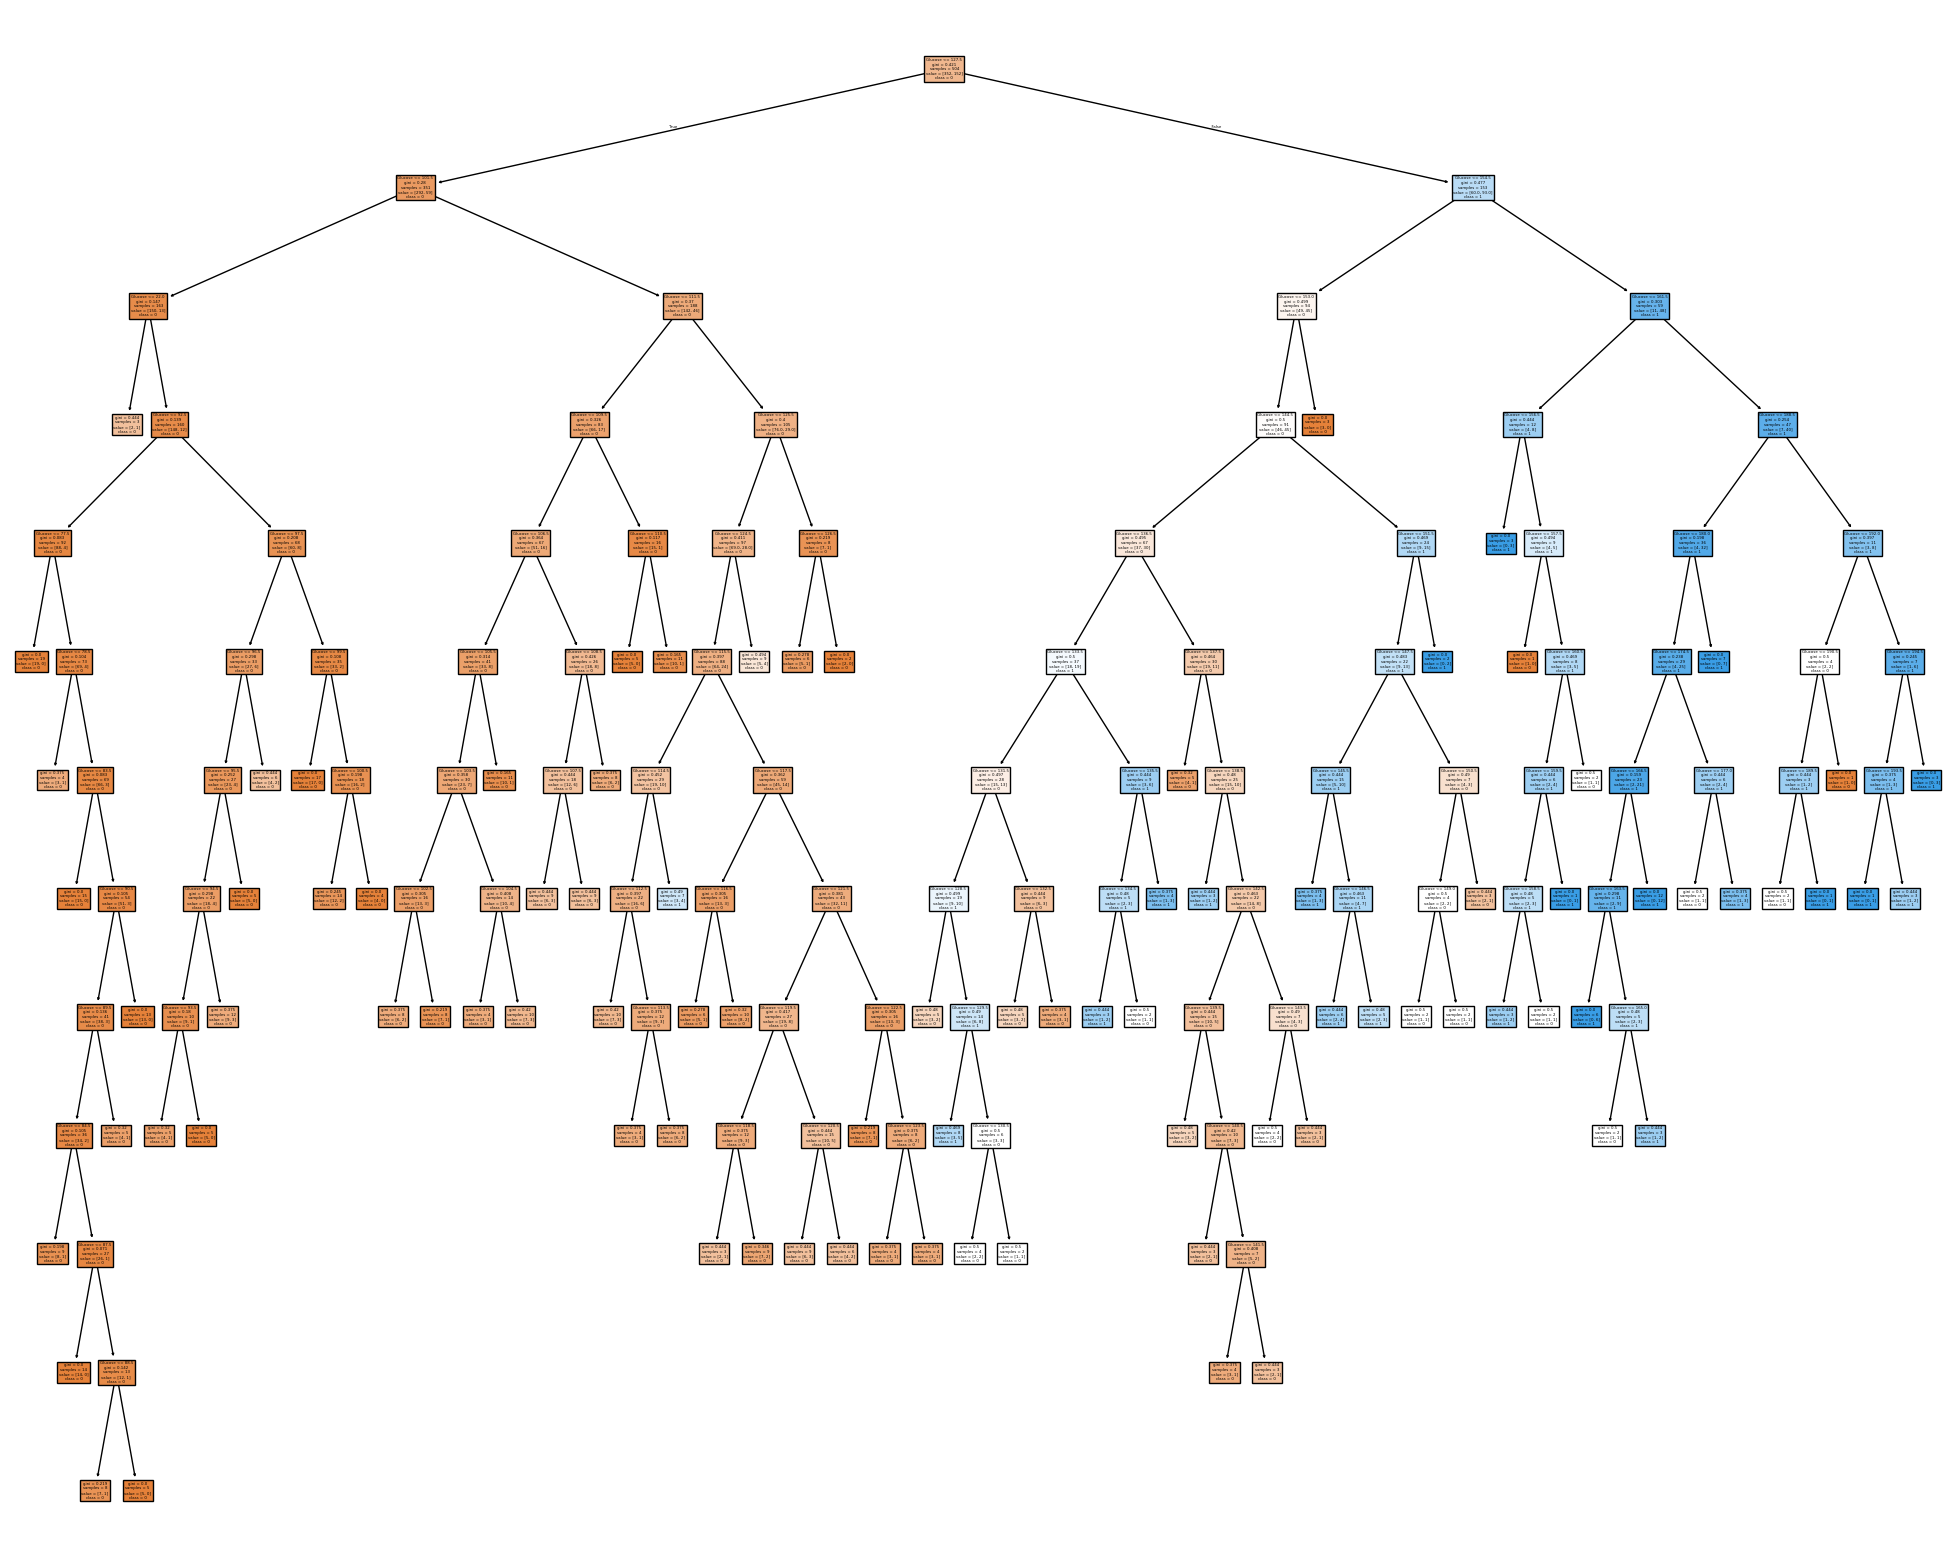

In [ ]:
# Visualizamos el Arbol de Decision
fig = plt.figure(figsize=(25,20))
trained = tree.plot_tree(model, feature_names=X_train.columns, class_names=['0', '1'], filled=True)
plt.show()

In [ ]:
#Evaluamos el modelo con los datos de prueba
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
# Evaluamos la precisión del modelo utilizando la métrica de Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.71


In [ ]:
# Evaluamos el reporte de clasificación
class_report = classification_report(y_test, y_pred)
print(class_report)


              precision    recall  f1-score   support

           0       0.72      0.90      0.80        83
           1       0.65      0.34      0.45        44

    accuracy                           0.71       127
   macro avg       0.69      0.62      0.62       127
weighted avg       0.70      0.71      0.68       127



Text(50.722222222222214, 0.5, 'Predicted')

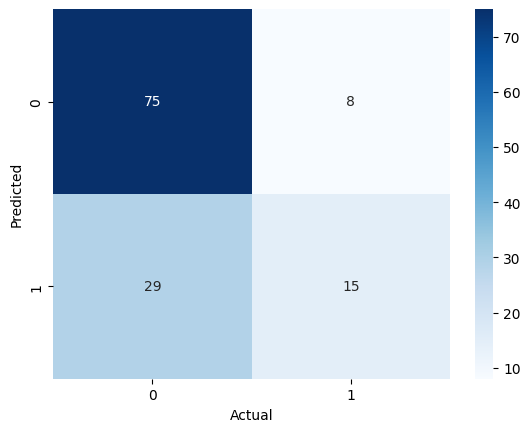

In [ ]:
# Evaluamos el modelo usando la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Actual')
plt.ylabel('Predicted')

### 5. Optimizamos el modelo con Skopt-Bayes

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

opt = BayesSearchCV(
        model,
        search_spaces={
            'max_depth': [1, 10],
            'min_samples_split': [2, 10],
            'min_samples_leaf': [1, 10]
        },
        n_iter=32,
        cv=10,
        random_state=42

)

opt.fit(X_train, y_train)

print("Mejores Hiperparámetros:", opt.best_params_)

/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 5] was inferred to Integer(low=1, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(1, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 5] was inferred to Integer(low=1, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it wi

Mejores Hiperparámetros: OrderedDict([('max_depth', 3), ('min_samples_leaf', 1), ('min_samples_split', 2)])


In [ ]:
# Evaluamos el modelo optimizado con los datos de prueba
modelopt = opt.fit(X_train, y_train)
y_pred_opt = modelopt.predict(X_test)

#Evaluamos la Precision del modelo optimizado
accuracy_opt = accuracy_score(y_test, y_pred_opt)
print(f'Precision del modelo optimizado: {accuracy_opt:.2f}')

/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 5] was inferred to Integer(low=1, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(1, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 5] was inferred to Integer(low=1, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(1, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it wi

/home/vscode/.local/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(1), np.int64(5)] before, using random point [np.int64(2), np.int64(3), np.int64(4)]
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(1), np.int64(5)] before, using random point [np.int64(4), np.int64(1), np.int64(4)]
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(1), np.int64(2)] before, using random point [np.int64(2), np.int64(2), np.int64(3)]
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(1), np.int64(2)] before, using random point [np.int64

Precision del modelo optimizado: 0.72


In [ ]:
#Evaluamos el reporte de clasificación del modelo optimizado
class_report_opt = classification_report(y_test, y_pred_opt)
print(class_report_opt)

              precision    recall  f1-score   support

           0       0.72      0.95      0.82        83
           1       0.76      0.30      0.43        44

    accuracy                           0.72       127
   macro avg       0.74      0.62      0.62       127
weighted avg       0.73      0.72      0.68       127



Text(50.722222222222214, 0.5, 'Predicted')

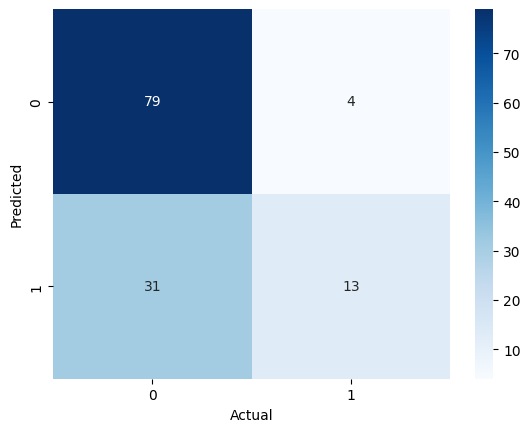

In [ ]:
#Evaluamos la matriz de confusión del modelo optimizado
conf_matrix_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(conf_matrix_opt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Actual')
plt.ylabel('Predicted')

### 6. Optimizamos con GridSearchCV

In [ ]:
hyper = {'max_depth': [1, 3],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 5]}

grid = GridSearchCV(model, hyper,cv=10, scoring='accuracy')
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 3], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [ ]:
modelgrid = grid.fit(X_train, y_train)
print("Mejores Hiperparámetros:", modelgrid.best_params_)

Mejores Hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
y_predict_grid = modelgrid.predict(X_test)
y_predict_grid

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0])

In [ ]:
#Evaluamos el modelo optimizado con GridSearchCV
accuracy_grid = accuracy_score(y_test, y_predict_grid)
print(f'Precision del modelo optimizado con GridSearchCV: {accuracy_grid:.2f}')

Precision del modelo optimizado con GridSearchCV: 0.72


In [ ]:
class_report_grid = classification_report(y_test, modelgrid.predict(X_test))
print(class_report_grid)

              precision    recall  f1-score   support

           0       0.72      0.95      0.82        83
           1       0.76      0.30      0.43        44

    accuracy                           0.72       127
   macro avg       0.74      0.62      0.62       127
weighted avg       0.73      0.72      0.68       127



Text(50.722222222222214, 0.5, 'Predicted')

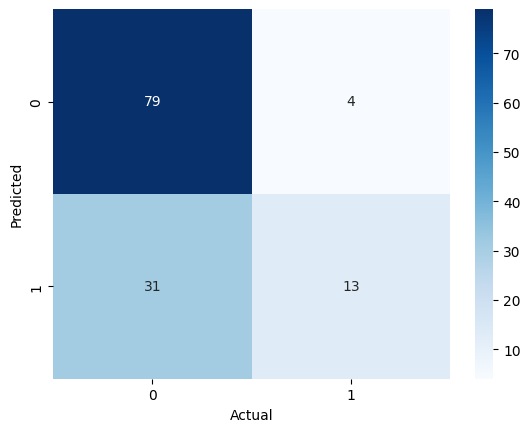

In [ ]:
conf_matrix_grid = confusion_matrix(y_test, y_predict_grid)
sns.heatmap(conf_matrix_grid, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Actual')
plt.ylabel('Predicted')

### 7. Guardamos el modelo

In [ ]:
from pickle import dump
dump(modelopt, open('/workspaces/P19-Decision-Tree/models/decision_tree_model.pkl', 'wb'))